In [3]:
import constants as c
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

vk = c.vk
vrf = c.vrf
z_offset = c.z0
xy1k = c.xy1k
xy2k = c.xy2k
pi = math.pi
um = c.um
cm = c.cm
mm = c.mm
K = c.K
e = c.e

eps = 1e-6
alpha = 1/137.06
d_chain = 3.7066438742e-06  # 3.7 µm separation between ions
delta_ion_2 = 0#-4.9903032463e-14 # small displacement of ion 2
m_dm = 1e-27
m_ion = c.m 
Z_ion = c.Z
freq_x = 719430.7131391969
freq_y = 3031200.0099101723
freq_z = 3002153.5607483205
omega = 2*pi*np.array([freq_x,freq_y,freq_z])
hbar = 1.0545718e-34 
mode_y = 2*pi*np.array([3031200.01,2944587.06,2818861.50])
mode_z = 2*pi*np.array([3002153.56,2914677.59,2787603.39])

In [4]:
"""
xyz : ndarray, shape (n, 3)
        DM particle positions.
"""
# RF pseudo-force
def FRF(xyz,m,Z,q=c.e,omrf=c.omega,VRF=c.vrf,ymin=c.y11,yedge1=c.y21,yedge2=c.y12,ymax=c.y22):
    xyz = np.asarray(xyz, dtype=float)
    if xyz.ndim != 2 or xyz.shape[1] != 3:
        raise ValueError("xyz must have shape (n, 3)")
    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]
    m = float(np.asarray(m).ravel()[0])
    Z = float(np.asarray(Z).ravel()[0])
    q = float(np.asarray(q).ravel()[0])
    omrf = float(np.asarray(omrf).ravel()[0])
    VRF = float(np.asarray(VRF).ravel()[0])
    #this is the pseudo potential, which is Z^2*(Div[PhiRF]/cos(om*t))^2/(4m*omega^2)
    divypart=divatan(z,yedge2-y)-divatan(z,yedge1-y)+divatan(z,ymin-y)-divatan(z,ymax-y)
    divzpart=divatan(yedge2-y,z)-divatan(yedge1-y,z)+divatan(ymin-y,z)-divatan(ymax-y,z) 
    divyparty=-2*divypart*(divatandown(z,yedge2-y)-divatandown(z,yedge1-y)+divatandown(z,ymin-y)-divatandown(z,ymax-y)) 
    divypartz=2*divypart*(divatanup(z,yedge2-y)-divatanup(z,yedge1-y)+divatanup(z,ymin-y)-divatanup(z,ymax-y)) 
    divzparty=-2*divzpart*(divatanup(yedge2-y,z)-divatanup(yedge1-y,z)+divatanup(ymin-y,z)-divatanup(ymax-y,z)) 
    divzpartz=2*divzpart*(divatandown(yedge2-y,z)-divatandown(yedge1-y,z)+divatandown(ymin-y,z)-divatandown(ymax-y,z)) 
    return -1*((VRF*Z*q)/(2*pi*np.sqrt(m)*omrf))**2*np.column_stack([divypartz*0, divzparty+divyparty, divzpartz+divypartz])

# DC force
def divatan(up,down):
    #This is d(arctan2(up,down))/ddown up to a minus sign. It's useful for the pseudo-potential
    return up/(up**2+down**2)
def divatanup(up,down):
    #This is d(divatan(up,down))/dup
    return (down**2-up**2)/(up**2+down**2)**2
def divatandown(up,down):
    #This is d(divatan(up,down))/ddown
    return -2*up*down/(up**2+down**2)**2

def anatangrad(xi,yi,xyz,v): # gradient term of DC potential
    xyz = np.asarray(xyz, dtype=float)
    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]
    dy=y-yi
    dx=x-xi
    r = np.sqrt(dx**2+dy**2+z**2); # added distance
    dry2=z**2+dy**2
    drx2=z**2+dx**2
    divy=z*dx/(r*dry2); # divide by factor r
    divz=-dy*dx*(1/dry2+1/drx2)/r; # divide by factor r
    divx=z*dy/(r*drx2); # divide by factor r
    return (v/(2*np.pi))*np.column_stack([divx, divy, divz])

def FDC_single(x1,y1,x2,y2,xyz,v,Z,q=c.e):
    return -Z*q * (anatangrad(x2,y2,xyz,v)-anatangrad(x2,y1,xyz,v)-anatangrad(x1,y2,xyz,v)+anatangrad(x1,y1,xyz,v))

def FDC(xyz, m, Z, q=c.e, omrf=c.omega,
        ymin=c.y11, yedge1=c.y21, yedge2=c.y12, ymax=c.y22):
    xyz = np.asarray(xyz, dtype=float)
    if xyz.ndim != 2 or xyz.shape[1] != 3:
        raise ValueError("xyz must have shape (n, 3)")
    z_original = xyz[:, 2].copy()
    force = np.zeros_like(xyz)
    for k in range(0, 40):
        xyz_k = xyz.copy()
        if (k != 19 and k != 39):
            xyz_k[:, 2] = z_original - z_offset  # keep scalar math
        else:
            xyz_k[:, 2] = z_original
        (x1k, y1k) = xy1k[k]
        (x2k, y2k) = xy2k[k]
        # enforce scalar on vk[k]
        v_k = float(np.asarray(vk[k]).ravel()[0])
        force_single = FDC_single(x1k, y1k, x2k, y2k, xyz_k, v_k, Z, q=q)
        # check shape of force_single 
        force_single = np.asarray(force_single, dtype=float)
        if force_single.shape != xyz.shape:
            raise ValueError(
                f"FDC_single returned unexpected shape {force_single.shape}; "
                f"expected {xyz.shape} at k={k}"
            )
        force += force_single
    return force

In [5]:
Z=Z_charge
q_dm=eps*e
omega_ion = omega
r_ions0 = [0,0,0]
x_zp = 5.436e-9

NameError: name 'Z_charge' is not defined

In [4]:
# Isabela
# ================================================================
# COMBINED TRAP FORCES
# ================================================================
def trap_force_ion(r):
    """Full trap force (DC + RF pseudopotential) on an ion."""
    return FDC(r[0], r[1], r[2]) + FRF(r[0], r[1], r[2]) # FRF_ion

def trap_force_dm(r):
    """Full trap force (DC + RF pseudopotential) on the DM particle."""
    return FDC(r[0], r[1], r[2]) + FRF(r[0], r[1], r[2]) # FRF_dm

# ================================================================
# EQUATIONS OF MOTION
# ================================================================

def rhs_dm_fixed(t, U, r_ions):
    r_dm = U[:3];  v_dm = U[3:]

    F = trap_force_dm(r_dm)
    for ri in r_ions:
        delta = r_dm - ri
        dist  = max(np.linalg.norm(delta), 1e-12)
        F    += K * q_dm * (Z*e) * delta / dist**3   # Coulomb: DM ← ion

    return np.concatenate([v_dm, F / m_dm])


def rhs_coupled_full(t, U, r_ions_eq):
    
    r_dm   = U[0:3];   v_dm   = U[3:6]
    r_ion1 = U[6:9];   v_ion1 = U[9:12]
    r_ion2 = U[12:15]; v_ion2 = U[15:18]
    r_ion3 = U[18:21]; v_ion3 = U[21:24]

    r_ions_now = [r_ion1, r_ion2, r_ion3]

    # --- DM acceleration ---
    F_dm = trap_force_dm(r_dm)
    for ri in r_ions_now:
        delta = r_dm - ri
        dist  = max(np.linalg.norm(delta), 1e-12)
        F_dm += K * q_dm * (Z*e) * delta / dist**3

    # --- Ion accelerations ---
    dv_ions = []
    for i, (ri, req) in enumerate(zip(r_ions_now, r_ions_eq)):
        # Harmonic restoring about equilibrium (approximation)
        F_ion = -m_ion * omega_ion**2 * (ri - req)

        # Coulomb from DM (reaction to DM-ion Coulomb above)
        delta_dm = ri - r_dm
        dist_dm  = max(np.linalg.norm(delta_dm), 1e-12)
        F_ion   += K * q_dm * (Z*e) * delta_dm / dist_dm**3

        # Ion–ion Coulomb
        for j, rj in enumerate(r_ions_now):
            if i == j:
                continue
            delta_ij = ri - rj
            dist_ij  = max(np.linalg.norm(delta_ij), 1e-12)
            F_ion   += K * (Z*e)**2 * delta_ij / dist_ij**3

        dv_ions.append(F_ion / m_ion)

    return np.concatenate([
        v_dm,   F_dm / m_dm,
        v_ion1, dv_ions[0],
        v_ion2, dv_ions[1],
        v_ion3, dv_ions[2],
    ])

# ================================================================
# ANALYSIS HELPERS
# ================================================================

def closest_approach(sol, r_ions):
    """Time/position/velocity of closest approach to ion chain CoM."""
    com   = np.mean(r_ions, axis=0)[:, None]
    dists = np.linalg.norm(sol.y[:3] - com, axis=0)
    idx   = np.argmin(dists)
    return sol.y[:3, idx], sol.y[3:6, idx], sol.t[idx], dists[idx]

def backprop_to_radius(r_start, v_start, r_ions, r_target):
    """Integrate DM backwards (in time) until it is r_target from ion CoM."""
    com = np.mean(r_ions, axis=0)

    def hit_radius(t, U, r_ions):
        return np.linalg.norm(U[:3] - com) - r_target
    hit_radius.terminal  = True
    hit_radius.direction = 1         # triggered when distance increases through r_target

    U0  = np.concatenate([r_start, v_start])
    sol = solve_ivp(rhs_dm_fixed,
                    (0, -1e-4), U0,
                    args=(r_ions,),
                    events=hit_radius,
                    rtol=1e-9, atol=1e-12,
                    max_step=2e-8)

    if sol.status != 1:
        print("WARNING: back-propagation did not reach target radius; using endpoint.")
    return sol.y[:3, -1], sol.y[3:6, -1], sol

def total_ion_energy(sol):
    """
    Total kinetic + harmonic PE (about equilibrium) for all 3 ions.
    State ordering: r_dm[0:3], v_dm[3:6],
                    r_ion_i[6+6i : 9+6i], v_ion_i[9+6i : 12+6i]
    """
    E = np.zeros(sol.y.shape[1])
    for i, req in enumerate(r_ions0):
        r_ion = sol.y[6 + 6*i : 9 + 6*i]
        v_ion = sol.y[9 + 6*i : 12 + 6*i]
        dr    = r_ion - req[:, None]
        E    += (0.5 * m_ion * np.sum(v_ion**2, axis=0)
               + 0.5 * m_ion * omega_ion**2 * np.sum(dr**2, axis=0))
    return E

# ================================================================
# MAIN
# ================================================================
if __name__ == "__main__":

    # --- DM initial conditions ---
    r_dm_far = np.array([-500*um, 200*um, 0.0])
    v_dm_far = np.array([80.0, 0.0, 0.0])          # m/s

    # ---- STAGE 1: forward propagation (ions fixed) ----
    print("=== STAGE 1: Forward DM propagation (ions fixed) ===")
    U0_s1 = np.concatenate([r_dm_far, v_dm_far])
    sol1  = solve_ivp(rhs_dm_fixed,
                      (0, 2e-3), U0_s1,
                      args=(r_ions0,),
                      rtol=1e-9, atol=1e-12,
                      max_step=2e-8)
    print("  Integrator success:", sol1.success, "—", sol1.message)

    r_dm_ca, v_dm_ca, t_ca, d_ca = closest_approach(sol1, r_ions0)
    print(f"  Closest approach: t = {t_ca:.3e} s,  d = {d_ca*1e6:.3f} µm")

    # ---- STAGE 2: back-propagate to 30 µm ----
    print("\n=== STAGE 2: Back-propagation to 30 µm ===")
    r_30, v_30, _ = backprop_to_radius(r_dm_ca, v_dm_ca, r_ions0, 30*um)
    print(f"  DM position at 30 µm: {r_30}")
    print(f"  DM velocity at 30 µm: {v_30}")

    # ---- STAGE 3: full coupled run ----
    print("\n=== STAGE 3: Full coupled DM + 3 ions ===")
    v_ions0 = np.zeros((3, 3))          # ions start at rest at equilibrium

    U0_s3 = np.concatenate([
        r_30, v_30,
        r_ions0[0], v_ions0[0],
        r_ions0[1], v_ions0[1],
        r_ions0[2], v_ions0[2],
    ])

    sol3 = solve_ivp(rhs_coupled_full,
                     (0, 5e-6), U0_s3,
                     args=(r_ions0,),
                     rtol=1e-9, atol=1e-12,
                     max_step=3e-9)
    print("  Integrator success:", sol3.success, "—", sol3.message)

    # ---- Analysis ----
    E_t   = total_ion_energy(sol3)
    E_max = np.max(E_t)
    print(f"\nMax total ion energy : {E_max:.3e} J")
    print(f"ℏω                   : {hbar*omega_ion:.3e} J")
    print(f"Phonon number ~       : {E_max / (hbar*omega_ion):.3f}")
    print(f"Zero-point amplitude : {x_zp*1e12:.3f} pm")

    for i, req in enumerate(r_ions0):
        r_traj = sol3.y[6 + 6*i : 9 + 6*i].T
        disp   = np.linalg.norm(r_traj - req, axis=1)
        print(f"  Ion {i+1} max displacement: {np.max(disp)*1e9:.3f} nm")

=== STAGE 1: Forward DM propagation (ions fixed) ===


KeyboardInterrupt: 

Initial DM position: [ 2.11297150e-22 -2.32848015e-06 -3.13452024e-05]
Initial DM velocity: [-1.74379576e-13  1.80241199e+04  8.22121480e+04]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 4.999e-06
Ending position of DM: [-6.55300523e-19  1.54743134e-02 -4.49658231e-01]
Ending velocity of DM: [-1.30668650e-13  3.09749744e+03 -8.99701421e+04]
Maximum distance of ion 1 from equilibrium: 1.6652097537793413e-09
Elementary charge: 1.62176634e-19


C:\Users\potha\AppData\Local\Temp\ipykernel_14516\821275905.py:133: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\potha\AppData\Local\Temp\ipykernel_14516\821275905.py:141: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\potha\AppData\Local\Temp\ipykernel_14516\821275905.py:149: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


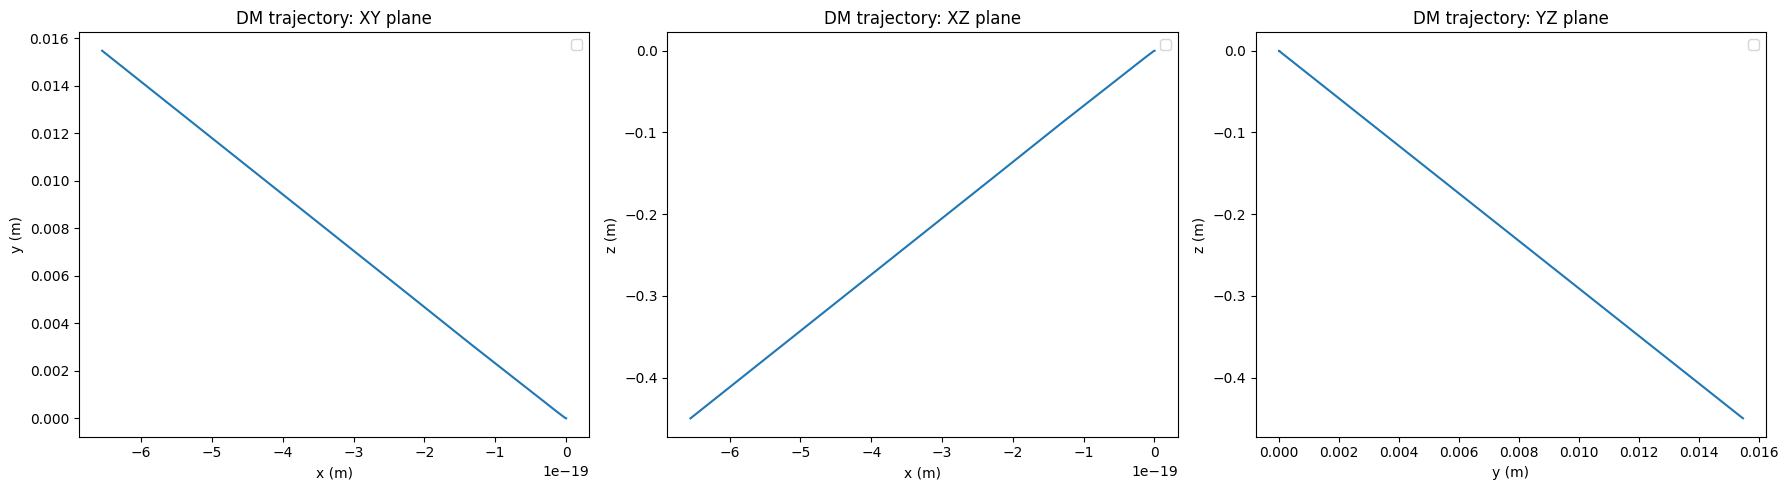

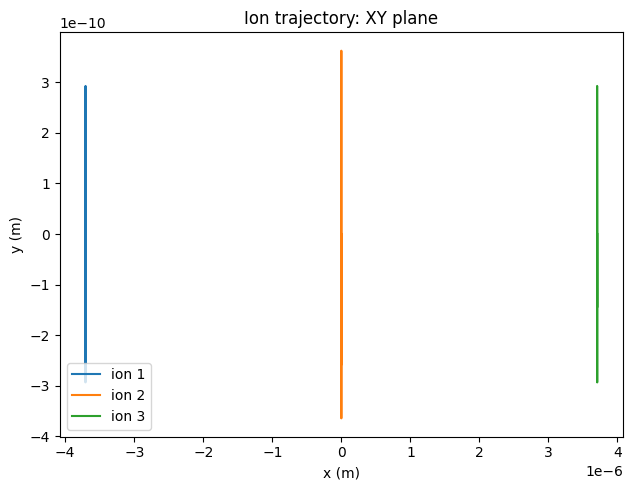

C:\Users\potha\AppData\Local\Temp\ipykernel_14516\821275905.py:215: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


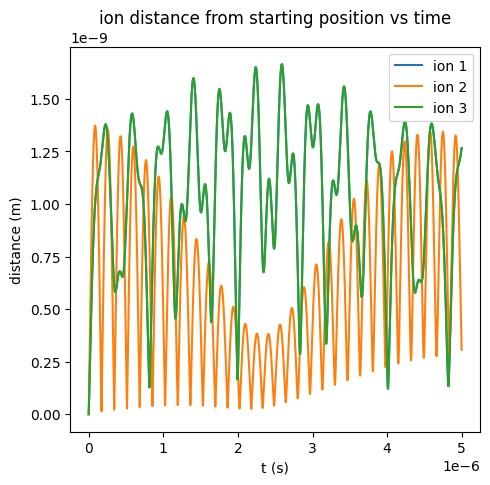

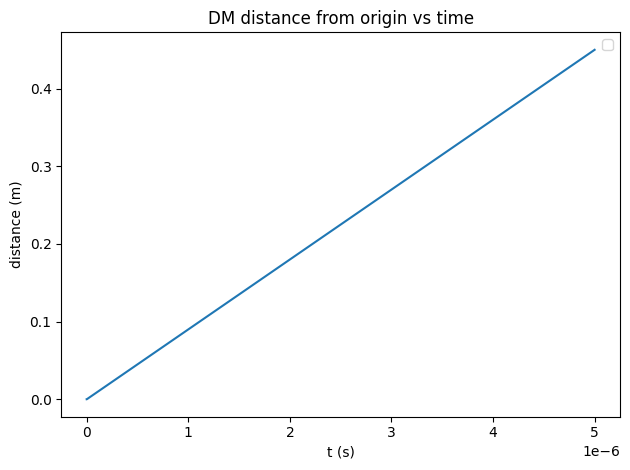

In [17]:
# Pothan

def run_simulation():

    # coupled ODE system 
    def fun2(t, U, req_ions):
        """
        Robust ODE RHS:
        - uses Plummer softening for Coulomb: replace r^3 by (r^2 + a^2)^(3/2)
        - calls FRF/FDC with Python floats and reduces any (3,N) output to the column nearest t
        """
        n_ions = 3
        x_ions = U[0:3*n_ions].reshape((n_ions,3))
        x_dm   = U[3*n_ions:3*n_ions+3].astype(float)
        v_ions = U[3*n_ions+3:3*n_ions+3*n_ions+3].reshape((n_ions,3))
        v_dm   = U[-3:].astype(float)

        # --- trap field calls (safe scalars) ---
        dc_raw = FDC(float(x_dm[0]), float(x_dm[1]), float(x_dm[2]))
        rf_raw = FRF(float(x_dm[0]), float(x_dm[1]), float(x_dm[2]))

        dc_force = np.asarray(dc_raw)
        rf_force = np.asarray(rf_raw)

        E_trap = (dc_force + rf_force) / e   # V/m at DM (3,)

        # derivatives containers
        dx_ionsdt = v_ions
        dv_ionsdt = np.zeros_like(x_ions)

        # Ion equations
        for i in range(n_ions):
            # harmonic trap
            dv_ionsdt[i] += -omega**2 * (x_ions[i]-req_ions[i])

            # Coulomb with DM using Plummer softening:
            delta_dm = x_ions[i] - x_dm
            r2_dm = np.dot(delta_dm, delta_dm)
            denom_dm = (r2_dm)**1.5   
            dv_ionsdt[i] += K * eps * e**2 * delta_dm / (m_ion * denom_dm)

            # Coulomb with other ions (softened)
            for j in range(n_ions):
                if i == j:
                    continue
                delta_ij = x_ions[i] - x_ions[j]
                r2_ij = np.dot(delta_ij, delta_ij)
                denom_ij = (r2_ij)**1.5
                dv_ionsdt[i] += K * e**2 * delta_ij / (m_ion * denom_ij)
        
        # DM motion: trap contribution from E_trap plus Coulomb softening with ions
        dx_dmdt = v_dm
        # trap acceleration 
        E_trap = (dc_force + rf_force) / e      # if they are forces
        a_dm_trap = (eps * e / m_dm) * E_trap
        dv_dmdt = a_dm_trap.copy()

        for i in range(n_ions):
            delta_dm2 = x_dm - x_ions[i]
            r2_dm2 = np.dot(delta_dm2, delta_dm2)
            denom_dm2 = (r2_dm2)**1.5
            dv_dmdt += -K * eps * e**2 * delta_dm2 / (m_dm * denom_dm2)

        return np.concatenate([
            dx_ionsdt.flatten(), dx_dmdt,
            dv_ionsdt.flatten(), dv_dmdt
        ])
    
    # Initial conditions for 3-ion chain:
    x0_ions = np.array([
        [-d_chain,0,0],
        [delta_ion_2,0,0],
        [d_chain,0,0]
    ], dtype=float)
    v0_ions = np.zeros_like(x0_ions, dtype=float)
    
    # Initial conditions for DM
    b = 0e-6 # impact parameter
    x0_dm = np.array([2.1129714985500633e-22,-2.3284801494144364e-06,-3.134520244349659e-05], dtype=float)  
    v0_dm = np.array([-1.7437957579651323e-13,18024.119934083286,82212.14800628253], dtype=float)
    print("Initial DM position:", x0_dm)
    print("Initial DM velocity:", v0_dm)

    # Flatten initial state
    U0 = np.concatenate([x0_ions.flatten(), x0_dm, v0_ions.flatten(), v0_dm]).astype(float)

    # Solve
    dt = 1e-9
    t_span = (0, 5e-6)
    t_eval = np.arange(t_span[0], t_span[1], dt)
    r0_ions = np.zeros((3, 3), dtype=float)
    sol = solve_ivp(fun2, t_span, U0, method='DOP853',
                    t_eval=t_eval, dense_output=True,
                    rtol=1e-13, atol=1e-16, args=(r0_ions,))

    print("Success?", sol.success)
    print("Message:", sol.message)
    print("Final time:", sol.t[-1])

    # Extract solutions
    n_ions = 3
    x_ions_sol = sol.y[0:3*n_ions]
    x_dm_sol   = sol.y[3*n_ions:3*n_ions+3]   # (3, N)
    v_ions_sol = sol.y[3*n_ions+3:3*n_ions+3*n_ions+3]
    v_dm_sol   = sol.y[-3:]

    return t_eval, x_dm_sol, v_dm_sol, x_ions_sol

# Run simulations
t0, xdm0, vdm0, xion0 = run_simulation() 
x0, y0, z0 = xdm0
x0_ion1, y0_ion1, z0_ion1 = xion0[0], xion0[1], xion0[2] # motion of left ion
x0_ion2, y0_ion2, z0_ion2 = xion0[3], xion0[4], xion0[5] # motion of center ion
x0_ion3, y0_ion3, z0_ion3 = xion0[6], xion0[7], xion0[8] # motion of right ion
d = np.sqrt(x0**2 + y0**2 + z0**2) # for DM
d_ion1 = np.sqrt((x0_ion1+d_chain)**2+y0_ion1**2+z0_ion1**2)
d_ion2 = np.sqrt(x0_ion2**2+y0_ion2**2+z0_ion2**2)
d_ion3 = np.sqrt((x0_ion3-d_chain)**2+y0_ion3**2+z0_ion3**2)
print(f"Ending position of DM: {xdm0[:, -1]}")
print(f"Ending velocity of DM: {vdm0[:, -1]}")
print(f"Maximum distance of ion 1 from equilibrium: {max(d_ion1)}")
print(f"Elementary charge: {e}")

## Plots of the DM trajectory
plt.figure(figsize=(18,5))

# XY
plt.subplot(1,3,1)
plt.plot(x0, y0)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("DM trajectory: XY plane")
plt.legend()

# XZ
plt.subplot(1,3,2)
plt.plot(x0, z0)
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("DM trajectory: XZ plane")
plt.legend()

# YZ
plt.subplot(1,3,3)
plt.plot(y0, z0)
plt.xlabel("y (m)")
plt.ylabel("z (m)")
plt.title("DM trajectory: YZ plane")
plt.legend()

plt.tight_layout()
plt.show()

## Plots for ion trajectory
plt.figure(figsize=(18,5))

# ion 1 XY-trajectory
plt.subplot(1,3,1)
plt.plot(x0_ion1, y0_ion1, label="ion 1")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Ion trajectory: XY plane")
plt.legend()

# ion 2 XY-trajectory
plt.subplot(1,3,1)
plt.plot(x0_ion2, y0_ion2, label="ion 2")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Ion trajectory: XY plane")
plt.legend()

# ion 3 XY-trajectory
plt.subplot(1,3,1)
plt.plot(x0_ion3, y0_ion3, label="ion 3")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Ion trajectory: XY plane")
plt.legend()

plt.tight_layout()
plt.show()

# ion 1 distance vs time
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.plot(t0, d_ion1, label="ion 1")
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("ion distance from starting position vs time")
plt.legend()

# ion 2 distance vs time
plt.subplot(1,3,1)
plt.plot(t0, d_ion2, label="ion 2")
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("ion distance from starting position vs time")
plt.legend()

# ion 3 distance vs time
plt.subplot(1,3,1)
plt.plot(t0, d_ion3, label="ion 3")
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("ion distance from starting position vs time")
plt.legend()

# DM distance vs time
plt.figure()
plt.plot(t0, d)
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("DM distance from origin vs time")
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
### Combined
def run_simulation(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt):
    """
    Run the coupled ion-chain / dark-matter trajectory simulation.

    Parameters
    ----------
    x0_dm : array-like, shape (3,)
        Initial position of the dark matter particle.
    v0_dm : array-like, shape (3,)
        Initial velocity of the dark matter particle.
    x0_ions : array-like, shape (3, 3)
        Initial positions of the 3 ions (rows = ions, columns = x,y,z).
        Used to build the initial state vector U0.
    v0_ions : array-like, shape (3, 3)
        Initial velocities of the 3 ions.
    t_span : tuple (t_start, t_end)
        Start and end time of the integration.
    dt : float
        Time increment used to build the evaluation grid
        (t_eval = arange(t_start, t_end, dt)).

    Returns
    -------
    t_eval : ndarray
        Times at which the solution was evaluated.
    x_dm_sol : ndarray, shape (3, N)
        DM position trajectory.
    v_dm_sol : ndarray, shape (3, N)
        DM velocity trajectory.
    x_ions_sol : ndarray, shape (9, N)
        Ion position trajectories (flattened, 3 ions x 3 coords).
    """

    x0_dm   = np.asarray(x0_dm, dtype=float)
    v0_dm   = np.asarray(v0_dm, dtype=float)
    x0_ions = np.asarray(x0_ions, dtype=float)
    v0_ions = np.asarray(v0_ions, dtype=float)

    # Trap restoring force pulls every ion toward the origin (the trap's
    # null point). Equilibrium chain spacing emerges from the balance
    # between this confinement and ion-ion Coulomb repulsion -- it is
    # NOT imposed here.
    r_ions_eq = np.zeros((3, 3), dtype=float)

    def rhs_unified(t, U, r_ions_eq, use_harmonic_ions=True):
        n_ions = 3

        x_ions = U[0:3*n_ions].reshape((n_ions, 3))
        x_dm   = U[3*n_ions:3*n_ions+3]
        v_ions = U[3*n_ions+3:3*n_ions+3+3*n_ions].reshape((n_ions, 3))
        v_dm   = U[-3:]

        dx_ionsdt = v_ions
        dx_dmdt   = v_dm

        dv_ionsdt = np.zeros_like(x_ions)
        dv_dmdt   = np.zeros(3)

        # --- Trap field (DM always uses full field) ---
        dc_dm = np.asarray(FDC(*x_dm))
        rf_dm = np.asarray(FRF(*x_dm))
        E_dm  = (dc_dm + rf_dm) / e
        dv_dmdt += (eps * e / m_dm) * E_dm

        # --- Ion dynamics ---
        for i in range(n_ions):

            if use_harmonic_ions:
                # Linearized trap around the origin (trap's true center)
                dv_ionsdt[i] += -omega**2 * (x_ions[i] - r_ions_eq[i])
            else:
                # Full trap field (same as DM but charge Z*e)
                dc_i = np.asarray(FDC(*x_ions[i]))
                rf_i = np.asarray(FRF(*x_ions[i]))
                E_i  = (dc_i + rf_i) / e
                dv_ionsdt[i] += (Z * e / m_ion) * E_i

            # --- Coulomb: ion <-> DM ---
            delta = x_ions[i] - x_dm
            r = np.linalg.norm(delta)

            force = K * eps * e**2 * delta / r**3

            dv_ionsdt[i] += force / m_ion
            dv_dmdt      -= force / m_dm   # enforce symmetry

            # --- Coulomb: ion <-> ion ---
            for j in range(i+1, n_ions):
                delta_ij = x_ions[i] - x_ions[j]
                r_ij = np.linalg.norm(delta_ij)

                fij = K * e**2 * delta_ij / r_ij**3

                dv_ionsdt[i] += fij / m_ion
                dv_ionsdt[j] -= fij / m_ion

        return np.concatenate([
            dx_ionsdt.flatten(), dx_dmdt,
            dv_ionsdt.flatten(), dv_dmdt
        ])

    print("Initial DM position:", x0_dm)
    print("Initial DM velocity:", v0_dm)

    # Flatten initial state
    U0 = np.concatenate([x0_ions.flatten(), x0_dm, v0_ions.flatten(), v0_dm]).astype(float)

    # Build time grid from t_span and dt
    t_eval = np.arange(t_span[0], t_span[1], dt)

    # Solve
    sol = solve_ivp(rhs_unified, t_span, U0, method='DOP853',
                     t_eval=t_eval, dense_output=True,
                     rtol=1e-13, atol=1e-16, args=(r_ions_eq,))

    print("Success?", sol.success)
    print("Message:", sol.message)
    print("Final time:", sol.t[-1])

    # Extract solutions
    n_ions = 3
    x_ions_sol = sol.y[0:3*n_ions]
    x_dm_sol   = sol.y[3*n_ions:3*n_ions+3]   # (3, N)
    v_ions_sol = sol.y[3*n_ions+3:3*n_ions+3*n_ions+3]
    v_dm_sol   = sol.y[-3:]

    return t_eval, x_dm_sol, v_dm_sol, x_ions_sol

Initial DM position: [ 2.11297150e-22 -2.32848015e-06 -3.13452024e-05]
Initial DM velocity: [-1.74379576e-13  1.80241199e+04  8.22121480e+04]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 4.999e-06
Ending position of DM: [-4.09590022e-18  1.51542850e-02 -4.49671684e-01]
Ending velocity of DM: [-8.19794819e-13  3.03346410e+03 -8.99728230e+04]


C:\Users\potha\AppData\Local\Temp\ipykernel_14516\1084559148.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\potha\AppData\Local\Temp\ipykernel_14516\1084559148.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\potha\AppData\Local\Temp\ipykernel_14516\1084559148.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


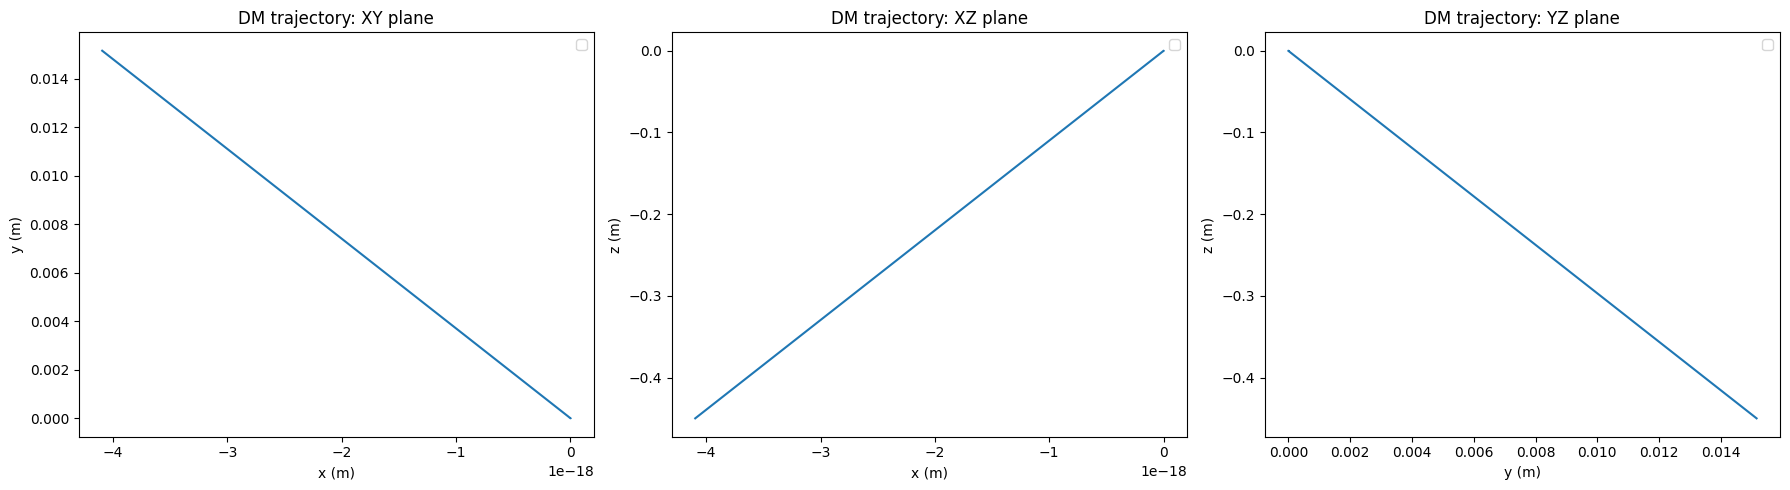

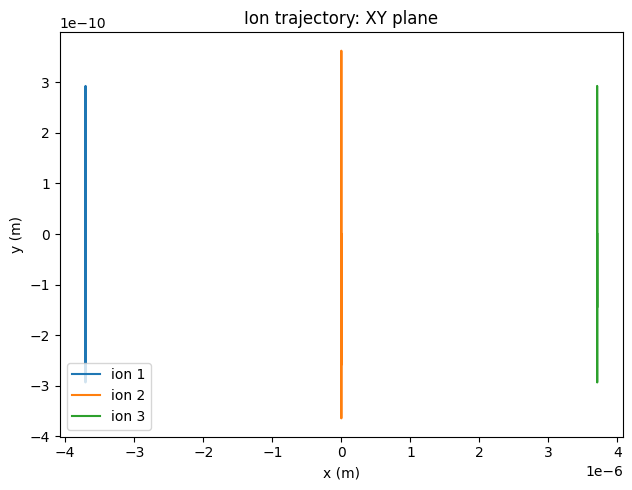

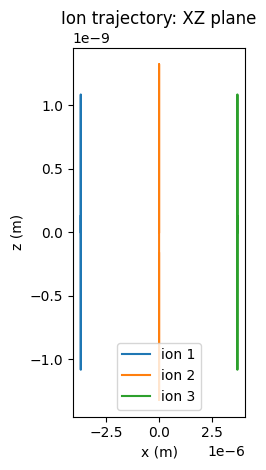

C:\Users\potha\AppData\Local\Temp\ipykernel_14516\1084559148.py:146: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


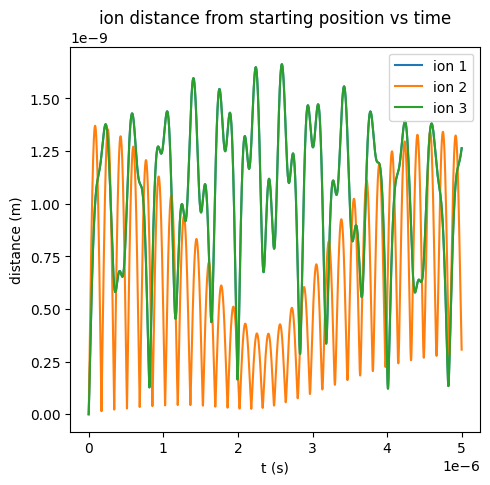

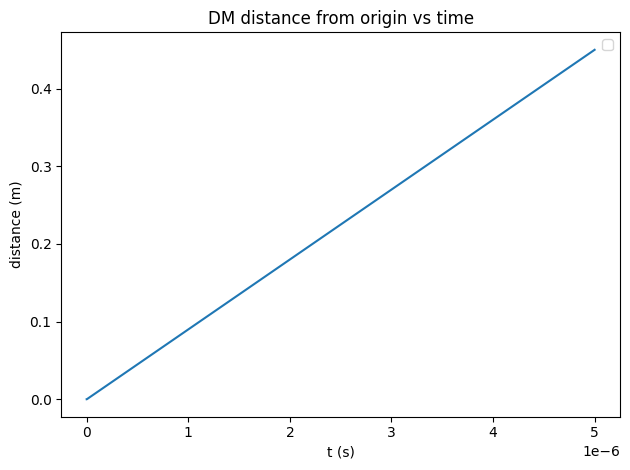

In [20]:
# Run simulation
x0_ions = np.array([
    [-d_chain, 0, 0],
    [delta_ion_2, 0, 0],
    [d_chain, 0, 0]
], dtype=float)
v0_ions = np.zeros_like(x0_ions, dtype=float)

b = 0e-6  # impact parameter
x0_dm = np.array([2.1129714985500633e-22, -2.3284801494144364e-06, -3.134520244349659e-05], dtype=float)
v0_dm = np.array([-1.7437957579651323e-13, 18024.119934083286, 82212.14800628253], dtype=float)

t_span = (0, 5e-6)
dt = 1e-9

t0, xdm0, vdm0, xion0 = run_simulation(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt)
x0, y0, z0 = xdm0
x0_ion1, y0_ion1, z0_ion1 = xion0[0], xion0[1], xion0[2] # motion of left ion
x0_ion2, y0_ion2, z0_ion2 = xion0[3], xion0[4], xion0[5] # motion of center ion
x0_ion3, y0_ion3, z0_ion3 = xion0[6], xion0[7], xion0[8] # motion of right ion
d = np.sqrt(x0**2 + y0**2 + z0**2) # for DM
d_ion1 = np.sqrt((x0_ion1+d_chain)**2+y0_ion1**2+z0_ion1**2)
d_ion2 = np.sqrt(x0_ion2**2+y0_ion2**2+z0_ion2**2)
d_ion3 = np.sqrt((x0_ion3-d_chain)**2+y0_ion3**2+z0_ion3**2)
print(f"Ending position of DM: {xdm0[:, -1]}")
print(f"Ending velocity of DM: {vdm0[:, -1]}")

## Plots of the DM trajectory
plt.figure(figsize=(18,5))

# XY
plt.subplot(1,3,1)
plt.plot(x0, y0)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("DM trajectory: XY plane")
plt.legend()

# XZ
plt.subplot(1,3,2)
plt.plot(x0, z0)
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("DM trajectory: XZ plane")
plt.legend()

# YZ
plt.subplot(1,3,3)
plt.plot(y0, z0)
plt.xlabel("y (m)")
plt.ylabel("z (m)")
plt.title("DM trajectory: YZ plane")
plt.legend()

plt.tight_layout()
plt.show()

## Plots for ion trajectory
plt.figure(figsize=(18,5))

# ion 1 XY-trajectory
plt.subplot(1,3,1)
plt.plot(x0_ion1, y0_ion1, label="ion 1")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Ion trajectory: XY plane")
plt.legend()

# ion 2 XY-trajectory
plt.subplot(1,3,1)
plt.plot(x0_ion2, y0_ion2, label="ion 2")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Ion trajectory: XY plane")
plt.legend()

# ion 3 XY-trajectory
plt.subplot(1,3,1)
plt.plot(x0_ion3, y0_ion3, label="ion 3")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Ion trajectory: XY plane")
plt.legend()

plt.tight_layout()
plt.show()

# ion 1 XZ-trajectory
plt.subplot(1,3,1)
plt.plot(x0_ion1, z0_ion1, label="ion 1")
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("Ion trajectory: XZ plane")
plt.legend()

# ion 2 XZ-trajectory
plt.subplot(1,3,1)
plt.plot(x0_ion2, z0_ion2, label="ion 2")
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("Ion trajectory: XZ plane")
plt.legend()

# ion 3 XZ-trajectory
plt.subplot(1,3,1)
plt.plot(x0_ion3, z0_ion3, label="ion 3")
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("Ion trajectory: XZ plane")
plt.legend()

plt.tight_layout()
plt.show()

# ion 1 distance vs time
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.plot(t0, d_ion1, label="ion 1")
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("ion distance from starting position vs time")
plt.legend()

# ion 2 distance vs time
plt.subplot(1,3,1)
plt.plot(t0, d_ion2, label="ion 2")
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("ion distance from starting position vs time")
plt.legend()

# ion 3 distance vs time
plt.subplot(1,3,1)
plt.plot(t0, d_ion3, label="ion 3")
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("ion distance from starting position vs time")
plt.legend()

# DM distance vs time
plt.figure()
plt.plot(t0, d)
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("DM distance from origin vs time")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# PASTE YOUR ACTUAL CONSTANTS HERE before running
# (omega, e, eps, m_ion, m_dm, K, Z, d_chain, FDC, FRF)
# This script assumes they already exist in scope when run
# inside your notebook -- e.g. paste this code into a cell
# AFTER you've defined those constants and FDC/FRF functions.
# ============================================================

def rhs_unified(t, U, r_ions_eq, use_harmonic_ions=True):
    """Version 1 RHS (copied verbatim, just renamed args for clarity)."""
    n_ions = 3

    x_ions = U[0:3*n_ions].reshape((n_ions, 3))
    x_dm   = U[3*n_ions:3*n_ions+3]
    v_ions = U[3*n_ions+3:3*n_ions+3+3*n_ions].reshape((n_ions, 3))
    v_dm   = U[-3:]

    dx_ionsdt = v_ions
    dx_dmdt   = v_dm

    dv_ionsdt = np.zeros_like(x_ions)
    dv_dmdt   = np.zeros(3)

    dc_dm = np.asarray(FDC(*x_dm))
    rf_dm = np.asarray(FRF(*x_dm))
    E_dm  = (dc_dm + rf_dm) / e
    dv_dmdt += (eps * e / m_dm) * E_dm

    for i in range(n_ions):
        if use_harmonic_ions:
            dv_ionsdt[i] += -omega**2 * (x_ions[i] - r_ions_eq[i])
        else:
            dc_i = np.asarray(FDC(*x_ions[i]))
            rf_i = np.asarray(FRF(*x_ions[i]))
            E_i  = (dc_i + rf_i) / e
            dv_ionsdt[i] += (Z * e / m_ion) * E_i

        delta = x_ions[i] - x_dm
        r = np.linalg.norm(delta)
        force = K * eps * e**2 * delta / r**3
        dv_ionsdt[i] += force / m_ion
        dv_dmdt      -= force / m_dm

        for j in range(i+1, n_ions):
            delta_ij = x_ions[i] - x_ions[j]
            r_ij = np.linalg.norm(delta_ij)
            fij = K * e**2 * delta_ij / r_ij**3
            dv_ionsdt[i] += fij / m_ion
            dv_ionsdt[j] -= fij / m_ion

    return np.concatenate([
        dx_ionsdt.flatten(), dx_dmdt,
        dv_ionsdt.flatten(), dv_dmdt
    ])


def fun2(t, U, req_ions):
    """Version 2 RHS (copied verbatim)."""
    n_ions = 3
    x_ions = U[0:3*n_ions].reshape((n_ions,3))
    x_dm   = U[3*n_ions:3*n_ions+3].astype(float)
    v_ions = U[3*n_ions+3:3*n_ions+3*n_ions+3].reshape((n_ions,3))
    v_dm   = U[-3:].astype(float)

    dc_raw = FDC(float(x_dm[0]), float(x_dm[1]), float(x_dm[2]))
    rf_raw = FRF(float(x_dm[0]), float(x_dm[1]), float(x_dm[2]))

    dc_force = np.asarray(dc_raw)
    rf_force = np.asarray(rf_raw)

    E_trap = (dc_force + rf_force) / e

    dx_ionsdt = v_ions
    dv_ionsdt = np.zeros_like(x_ions)

    for i in range(n_ions):
        dv_ionsdt[i] += -omega**2 * (x_ions[i]-req_ions[i])

        delta_dm = x_ions[i] - x_dm
        r2_dm = np.dot(delta_dm, delta_dm)
        denom_dm = (r2_dm)**1.5
        dv_ionsdt[i] += K * eps * e**2 * delta_dm / (m_ion * denom_dm)

        for j in range(n_ions):
            if i == j:
                continue
            delta_ij = x_ions[i] - x_ions[j]
            r2_ij = np.dot(delta_ij, delta_ij)
            denom_ij = (r2_ij)**1.5
            dv_ionsdt[i] += K * e**2 * delta_ij / (m_ion * denom_ij)

    dx_dmdt = v_dm
    E_trap = (dc_force + rf_force) / e
    a_dm_trap = (eps * e / m_dm) * E_trap
    dv_dmdt = a_dm_trap.copy()

    for i in range(n_ions):
        delta_dm2 = x_dm - x_ions[i]
        r2_dm2 = np.dot(delta_dm2, delta_dm2)
        denom_dm2 = (r2_dm2)**1.5
        dv_dmdt += -K * eps * e**2 * delta_dm2 / (m_dm * denom_dm2)

    return np.concatenate([
        dx_ionsdt.flatten(), dx_dmdt,
        dv_ionsdt.flatten(), dv_dmdt
    ])


def compare_rhs(U0, r_ions_eq, label):
    """Run both RHS functions on the same U0 and r_ions_eq, print a diff report."""
    out1 = rhs_unified(0.0, U0, r_ions_eq)
    out2 = fun2(0.0, U0, r_ions_eq)

    diff = out1 - out2
    max_abs_diff = np.max(np.abs(diff))
    # avoid divide-by-zero in relative diff
    denom = np.maximum(np.abs(out1), 1e-300)
    max_rel_diff = np.max(np.abs(diff) / denom)

    names = (
        [f"dx_ion{i+1}_{c}" for i in range(3) for c in "xyz"] +
        [f"dx_dm_{c}" for c in "xyz"] +
        [f"dv_ion{i+1}_{c}" for i in range(3) for c in "xyz"] +
        [f"dv_dm_{c}" for c in "xyz"]
    )

    print(f"\n=== {label} ===")
    print(f"max |out1 - out2|        = {max_abs_diff:.6e}")
    print(f"max relative difference  = {max_rel_diff:.6e}")
    print(f"{'component':<14}{'rhs_unified':>18}{'fun2':>18}{'abs diff':>14}")
    for name, v1, v2, d in zip(names, out1, out2, diff):
        flag = "  <-- DIFFERS" if abs(d) > 1e-12 * max(abs(v1), 1) else ""
        print(f"{name:<14}{v1:>18.10e}{v2:>18.10e}{abs(d):>14.3e}{flag}")

    return out1, out2, diff


if __name__ == "__main__":
    # --- Build a representative U0 exactly as in your simulation ---
    d_chain_val = d_chain  # uses whatever d_chain is in scope

    x0_ions = np.array([
        [-d_chain_val, 0, 0],
        [0, 0, 0],
        [d_chain_val, 0, 0]
    ], dtype=float)
    v0_ions = np.zeros_like(x0_ions, dtype=float)

    x0_dm = np.array([2.1129714985500633e-22, -2.3284801494144364e-06, -3.134520244349659e-05], dtype=float)
    v0_dm = np.array([-1.7437957579651323e-13, 18024.119934083286, 82212.14800628253], dtype=float)

    U0 = np.concatenate([x0_ions.flatten(), x0_dm, v0_ions.flatten(), v0_dm]).astype(float)

    # Case A: r_ions_eq = chain offsets (the case where you said results MATCH)
    r_eq_chain = np.array([
        [-d_chain_val, 0, 0],
        [0, 0, 0],
        [d_chain_val, 0, 0]
    ], dtype=float)
    compare_rhs(U0, r_eq_chain, "r_ions_eq = chain offsets (expected: match)")

    # Case B: r_ions_eq = zeros (the case where you said results DIFFER)
    r_eq_zero = np.zeros((3, 3), dtype=float)
    compare_rhs(U0, r_eq_zero, "r_ions_eq = zeros (expected: differ)")


=== r_ions_eq = chain offsets (expected: match) ===
max |out1 - out2|        = 1.374507e+09
max relative difference  = 5.631361e-05
component            rhs_unified              fun2      abs diff
dx_ion1_x       0.0000000000e+00  0.0000000000e+00     0.000e+00
dx_ion1_y       0.0000000000e+00  0.0000000000e+00     0.000e+00
dx_ion1_z       0.0000000000e+00  0.0000000000e+00     0.000e+00
dx_ion2_x       0.0000000000e+00  0.0000000000e+00     0.000e+00
dx_ion2_y       0.0000000000e+00  0.0000000000e+00     0.000e+00
dx_ion2_z       0.0000000000e+00  0.0000000000e+00     0.000e+00
dx_ion3_x       0.0000000000e+00  0.0000000000e+00     0.000e+00
dx_ion3_y       0.0000000000e+00  0.0000000000e+00     0.000e+00
dx_ion3_z       0.0000000000e+00  0.0000000000e+00     0.000e+00
dx_dm_x        -1.7437957580e-13 -1.7437957580e-13     0.000e+00
dx_dm_y         1.8024119934e+04  1.8024119934e+04     0.000e+00
dx_dm_z         8.2212148006e+04  8.2212148006e+04     0.000e+00
dv_ion1_x      -7.4078